# FDCH1 – Fraud Detection Assignment

**Dataset used:** Fraud Detection Dataset.csv  
**Tasks:** Sampling (Tasks 1–4), Data Selection, and ML Model (Task 5).

> The faculty notebook uses the word **Country** in Tasks 2–4, but the supplied fraud dataset contains **Location** as the geographic field. Therefore, `Location` is used as the country-wise grouping field for these tasks. The fraud target in this dataset is `Fraudulent` (not `Fraud`).

In [1]:
# Install only if needed
# %pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
DATA_PATH = 'Fraud Detection Dataset(1).csv'
df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset shape: (51000, 12)
Columns: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


## Initial dataset inspection

In [2]:
print('Data types:')
print(df.dtypes)

print('Missing values:')
print(df.isna().sum())

print('Duplicate rows:', df.duplicated().sum())

print('Fraudulent class distribution:')
print(df['Fraudulent'].value_counts())
print('Fraudulent class proportion:')
print(df['Fraudulent'].value_counts(normalize=True).rename('proportion'))

Data types:
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object
Missing values:
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method      

# Partition

In [3]:
# Faculty-provided 70% partition, retained for the supplied notebook structure.
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=RANDOM_STATE)
print('Partition size:', len(partition))
print('Partition percentage:', len(partition) / len(df) * 100)

Partition size: 35700
Partition percentage: 70.0


# Random sampling

In [4]:
# Task 1: Fix Number of Sample (500 only)
sample_random_500 = df.sample(n=500, random_state=RANDOM_STATE)
print('Random sample size:', len(sample_random_500))
sample_random_500.head()

Random sample size: 500


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


### Task 1
**Requirement:** Fix the number of samples to exactly **500**. The code above returns exactly 500 observations.

# Task 2 – Location-wise list/count

In [5]:
# The original faculty notebook refers to Country.
# This fraud dataset has Location, so Location is used for the geographic count.
location_counts = df['Location'].value_counts(dropna=False)
print('Location-wise counts including missing Location:')
print(location_counts)

print('Non-missing Location counts:')
print(df['Location'].dropna().value_counts())

Location-wise counts including missing Location:
Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
NaN              2547
Name: count, dtype: int64
Non-missing Location counts:
Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
Name: count, dtype: int64


### Task 2
The location-wise list/count is generated above. Missing `Location` values are shown separately rather than silently assigning them to a real location.

# Task 3 – Equalize the location-wise count

In [6]:
# Equalize the non-missing locations to the smallest observed non-missing location count.
location_nonmissing = df.dropna(subset=['Location']).copy()
min_location_count = location_nonmissing['Location'].value_counts().min()

sample_equal_location = (
    location_nonmissing.groupby('Location', group_keys=False)
    .apply(lambda x: x.sample(n=min_location_count, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print('Target equal count per location:', min_location_count)
print('Equalized dataset size:', len(sample_equal_location))
print('Counts after equalization:')
print(sample_equal_location['Location'].value_counts().sort_index())

Target equal count per location: 5985
Equalized dataset size: 47880
Counts after equalization:
Location
Boston           5985
Chicago          5985
Houston          5985
Los Angeles      5985
Miami            5985
New York         5985
San Francisco    5985
Seattle          5985
Name: count, dtype: int64


/tmp/ipykernel_807/1757262496.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_location_count, random_state=RANDOM_STATE))


### Task 3
Each non-missing location is reduced to the same count: the count of the least represented non-missing location. This produces a balanced location-wise sample without inventing observations.

# Cluster

In [7]:
# Faculty-provided cluster-style sample: randomly select two geographic groups.
locations = df['Location'].dropna().unique()
selected_locations = pd.Series(locations).sample(n=2, random_state=RANDOM_STATE).tolist()
sample_cluster = df[df['Location'].isin(selected_locations)].copy()

print('Selected locations:', selected_locations)
print('Cluster sample size:', len(sample_cluster))
sample_cluster.head(36)

Selected locations: ['New York', 'Miami']
Cluster sample size: 12101


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0
22,T23,1769,2222.86,POS Payment,14.0,Mobile,Miami,1,103,10,UPI,0
25,T26,4485,NaN,Online Purchase,17.0,Mobile,Miami,2,63,8,UPI,0
26,T27,3853,4065.44,Online Purchase,21.0,Tablet,New York,4,99,9,Net Banking,0
30,T31,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
32,T33,1459,2212.25,Online Purchase,10.0,Desktop,New York,4,14,13,UPI,0


# Task 4 – Sample from 5 most / 5 least listed locations

In [8]:
location_counts_nonmissing = df['Location'].dropna().value_counts()

top5_locations = location_counts_nonmissing.nlargest(5)
bottom5_locations = location_counts_nonmissing.nsmallest(5)

print('5 most listed locations:')
print(top5_locations)
print('5 least listed locations:')
print(bottom5_locations)

# Take a fixed-size sample from each selected location.
# 50 is used so every selected location contributes the same number of records.
SAMPLE_PER_LOCATION = 50

def sample_by_locations(data, selected):
    parts = []
    for loc in selected.index:
        group = data[data['Location'] == loc]
        parts.append(group.sample(n=min(SAMPLE_PER_LOCATION, len(group)), random_state=RANDOM_STATE))
    return pd.concat(parts, ignore_index=True)

sample_top5 = sample_by_locations(df, top5_locations)
sample_bottom5 = sample_by_locations(df, bottom5_locations)

print('Top-5 sample size:', len(sample_top5))
print('Bottom-5 sample size:', len(sample_bottom5))

5 most listed locations:
Location
Boston      6149
New York    6110
Seattle     6104
Chicago     6071
Houston     6031
Name: count, dtype: int64
5 least listed locations:
Location
San Francisco    5985
Miami            5991
Los Angeles      6012
Houston          6031
Chicago          6071
Name: count, dtype: int64
Top-5 sample size: 250
Bottom-5 sample size: 250


# Data Selection

## 1. Missing Value

In [9]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage': (df.isna().mean() * 100).round(2)
})
print(missing_summary)

# Modeling strategy: numeric variables -> median; categorical variables -> most frequent.
# Missing values are imputed inside the ML preprocessing pipeline to avoid data leakage.

                                  Missing_Count  Missing_Percentage
Transaction_ID                                0                0.00
User_ID                                       0                0.00
Transaction_Amount                         2520                4.94
Transaction_Type                              0                0.00
Time_of_Transaction                        2552                5.00
Device_Used                                2473                4.85
Location                                   2547                4.99
Previous_Fraudulent_Transactions              0                0.00
Account_Age                                   0                0.00
Number_of_Transactions_Last_24H               0                0.00
Payment_Method                             2469                4.84
Fraudulent                                    0                0.00


## 2. Identical Values

In [10]:
duplicate_count = df.duplicated().sum()
print('Number of identical/duplicate rows:', duplicate_count)

# Remove exact duplicate rows before modeling.
df_model = df.drop_duplicates().reset_index(drop=True)
print('Rows before duplicate removal:', len(df))
print('Rows after duplicate removal:', len(df_model))

Number of identical/duplicate rows: 881


Rows before duplicate removal: 51000
Rows after duplicate removal: 50119


## 3. Correlation Analysis

Correlation with Fraudulent:
Fraudulent                          1.000000
User_ID                             0.008046
Time_of_Transaction                 0.007035
Account_Age                         0.006203
Transaction_Amount                  0.005507
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64


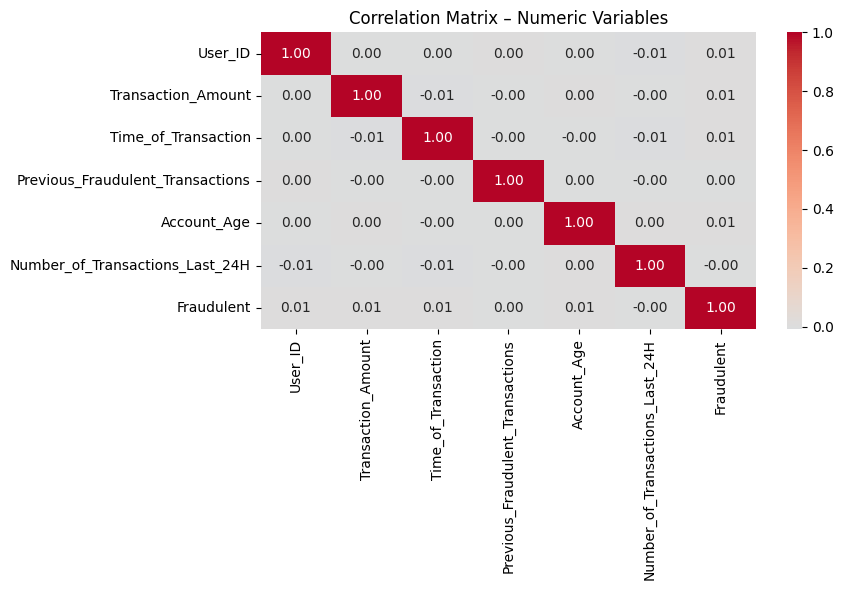

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns
corr = df[numeric_columns].corr()

print('Correlation with Fraudulent:')
print(corr['Fraudulent'].sort_values(ascending=False))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix – Numeric Variables')
plt.tight_layout()
plt.show()

## 4. Chi-Square Test

In [12]:
# Chi-square feature selection requires non-negative numeric inputs.
# Categorical variables are one-hot encoded; numeric variables are imputed and kept non-negative
# using Min-Max scaling. The target is Fraudulent.
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2

X_chi = df_model.drop(columns=['Fraudulent', 'Transaction_ID'])
y_chi = df_model['Fraudulent']

cat_cols_chi = X_chi.select_dtypes(include='object').columns.tolist()
num_cols_chi = X_chi.select_dtypes(exclude='object').columns.tolist()

X_chi = X_chi.copy()
for c in num_cols_chi:
    X_chi[c] = X_chi[c].fillna(X_chi[c].median())
for c in cat_cols_chi:
    X_chi[c] = X_chi[c].fillna(X_chi[c].mode()[0])

X_cat = pd.get_dummies(X_chi[cat_cols_chi], drop_first=False, dtype=int)
X_num = pd.DataFrame(
    MinMaxScaler().fit_transform(X_chi[num_cols_chi]),
    columns=num_cols_chi, index=X_chi.index
)
X_chi_final = pd.concat([X_num, X_cat], axis=1)

chi_scores, chi_p = chi2(X_chi_final, y_chi)
chi_results = pd.DataFrame({
    'Feature': X_chi_final.columns,
    'Chi2_Score': chi_scores,
    'p_value': chi_p
}).sort_values(['p_value', 'Chi2_Score'])

print(chi_results.to_string(index=False))
print('Significant at alpha=0.05:')
print(chi_results[chi_results['p_value'] < 0.05].to_string(index=False))

                         Feature   Chi2_Score  p_value
                Location_Seattle 4.458633e+00 0.034725
                Location_Chicago 4.445791e+00 0.034987
              Device_Used_Tablet 2.172951e+00 0.140456
              Device_Used_Mobile 1.894527e+00 0.168692
 Transaction_Type_ATM Withdrawal 1.359220e+00 0.243673
Transaction_Type_Online Purchase 9.600334e-01 0.327178
                Location_Houston 8.249898e-01 0.363725
            Location_Los Angeles 7.180776e-01 0.396775
                         User_ID 4.329027e-01 0.510568
               Location_New York 3.912944e-01 0.531620
             Time_of_Transaction 2.848291e-01 0.593553
              Transaction_Amount 2.608258e-01 0.609553
                     Account_Age 2.590550e-01 0.610770
  Transaction_Type_Bank Transfer 2.394045e-01 0.624637
    Transaction_Type_POS Payment 1.695284e-01 0.680531
 Number_of_Transactions_Last_24H 1.506596e-01 0.697906
          Location_San Francisco 7.424397e-02 0.785255
   Transac

# Task 5 – ML Model

The supplied fraud dataset uses **`Fraudulent`** as the target. `Transaction_ID` is an identifier and is excluded from modeling. Missing numeric values are median-imputed and categorical values are mode-imputed, followed by one-hot encoding. Exact duplicate rows are removed before the train/test split. Because fraud is highly imbalanced, Random Over-Sampling is applied **only to the training set**.

In [13]:
# Prepare modeling data
df_model = df.drop_duplicates().reset_index(drop=True)

X = df_model.drop(columns=['Fraudulent', 'Transaction_ID'])
y = df_model['Fraudulent']

print('Modeling rows:', len(df_model))
print('Target distribution before split:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print('Encoded training shape:', X_train_encoded.shape)
print('Encoded test shape:', X_test_encoded.shape)

# Balance only the training data.
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_encoded, y_train)

print('Training target before oversampling:')
print(y_train.value_counts())
print('Training target after oversampling:')
print(pd.Series(y_train_balanced).value_counts())

Modeling rows: 50119
Target distribution before split:
Fraudulent
0    47652
1     2467
Name: count, dtype: int64
Encoded training shape: (40095, 28)
Encoded test shape: (10024, 28)
Training target before oversampling:
Fraudulent
0    38121
1     1974
Name: count, dtype: int64
Training target after oversampling:
Fraudulent
0    38121
1    38121
Name: count, dtype: int64


In [14]:
# Logistic Regression classifier
# Logistic regression provides a useful interpretable baseline for this highly imbalanced dataset.
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test_encoded)
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Average Precision'],
    'Value': [accuracy, precision, recall, f1, roc_auc, ap]
})
print('Model metrics:')
print(metrics.to_string(index=False))

              precision    recall  f1-score   support

           0     0.9486    0.5155    0.6680      9531
           1     0.0469    0.4604    0.0851       493

    accuracy                         0.5128     10024
   macro avg     0.4977    0.4880    0.3765     10024
weighted avg     0.9043    0.5128    0.6393     10024

Model metrics:
           Metric    Value
         Accuracy 0.512769
        Precision 0.046852
           Recall 0.460446
         F1-Score 0.085051
          ROC-AUC 0.488325
Average Precision 0.048523


Confusion matrix:
[[4913 4618]
 [ 266  227]]


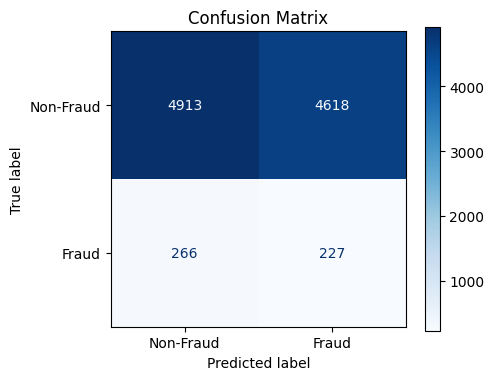

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud']).plot(ax=ax, values_format='d', cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

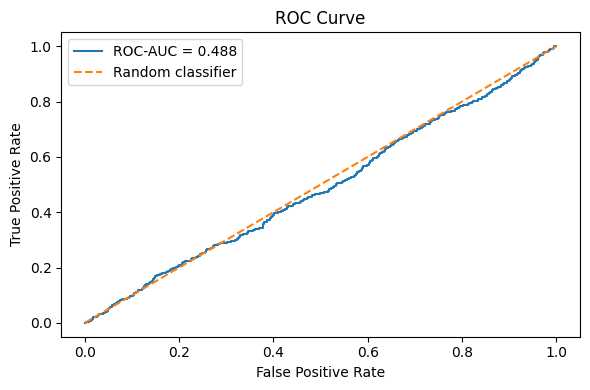

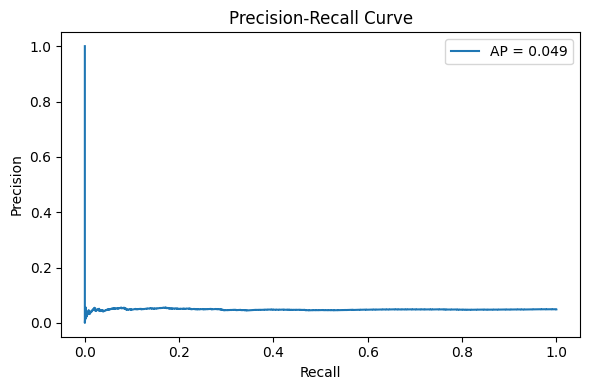

In [16]:
# ROC curve and Precision-Recall curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AP = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Result Analysis

In [17]:
print('RESULT ANALYSIS')
print('----------------')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Average Precision: {ap:.4f}')

print('Interpretation:')
print('- The dataset is strongly imbalanced, with fraud representing about 5% of transactions.')
print('- Oversampling was applied only to the training set so that the test set remains representative of the original distribution.')
print('- Accuracy alone is not sufficient for fraud detection; recall, precision, F1-score, ROC-AUC and Average Precision should also be considered.')
print('- The supplied variables show very weak linear correlation with the Fraudulent target, so limited predictive performance is plausible.')
print('- The final model results should therefore be interpreted as a baseline for this supplied dataset, not as evidence of a production-ready fraud detector.')

RESULT ANALYSIS
----------------
Accuracy: 0.5128
Precision: 0.0469
Recall: 0.4604
F1-score: 0.0851
ROC-AUC: 0.4883
Average Precision: 0.0485
Interpretation:
- The dataset is strongly imbalanced, with fraud representing about 5% of transactions.
- Oversampling was applied only to the training set so that the test set remains representative of the original distribution.
- Accuracy alone is not sufficient for fraud detection; recall, precision, F1-score, ROC-AUC and Average Precision should also be considered.
- The supplied variables show very weak linear correlation with the Fraudulent target, so limited predictive performance is plausible.
- The final model results should therefore be interpreted as a baseline for this supplied dataset, not as evidence of a production-ready fraud detector.


## Assignment completion note

All five tasks from the supplied faculty notebook are addressed using the fraud dataset. The only terminology adjustment is **Country → Location**, because `Country` does not exist in the supplied dataset. Likewise, the target is **Fraudulent**, which is the actual target column in the fraud dataset. No artificial `Fraud` or `Country` columns were created.